This code performs hyperparameter optimization for a Gaussian Process (GP), focusing on three parameters: length scale, coefficient, and noise. The optimization is conducted without imposing any upper or lower bounds on these parameters. In a separate section, we also explored bounded optimization to constrain the parameter search space. The optimized hyperparameter values obtained here are later applied in the GP model building. We used 3 kernel functions: RBF, Laplace, and Cauchy


GP Hyperparameters without bounds

In [5]:
# Hyper-parameters GP (No Bound)
import numpy as np
import tensorflow as tf
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
import pandas as pd

class GPHyperOpt:
    def __init__(self, kernel="laplace"):
        self.kernel = kernel
        self.log_lengthscale = tf.Variable(np.log(1.0), dtype=tf.float64)  # Initial guess
        self.log_coefficient = tf.Variable(np.log(1.0), dtype=tf.float64)  # Initial guess
        self.log_noise = tf.Variable(np.log(0.01), dtype=tf.float64)       # Initial guess
        self.scaler_X = None
        self.scaler_y = None
        self.X_train = None
        self.y_train = None

    def _covariance(self, x1, x2, noise=False):
        x1 = tf.convert_to_tensor(x1, dtype=tf.float64)
        x2 = tf.convert_to_tensor(x2, dtype=tf.float64)
        diff = tf.expand_dims(x1, 1) - tf.expand_dims(x2, 0)
        l = tf.exp(self.log_lengthscale)
        c = tf.exp(self.log_coefficient)

        if self.kernel == "laplace":
            l1 = tf.reduce_sum(tf.abs(diff / l), axis=2)
            cov = c**2 * tf.exp(-0.5 * l1)
        elif self.kernel == "eq":
            l2 = tf.reduce_sum((diff / l) ** 2, axis=2)
            cov = c**2 * tf.exp(-0.5 * l2)
        elif self.kernel == "cauchy":
            l2 = tf.reduce_sum((diff ** 2), axis=2)
            cov = c**2 / (1.0 + l2 / (l ** 2))
        else:
            raise ValueError("Unknown kernel")

        if noise:
            cov += tf.exp(self.log_noise) ** 2 * tf.eye(tf.shape(cov)[0], dtype=tf.float64)
        return cov

    def fit(self, X_train, y_train, methods):
        # Normalize
        self.scaler_X = StandardScaler()
        self.X_train = self.scaler_X.fit_transform(X_train)
        self.scaler_y = StandardScaler()
        self.y_train = self.scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

        results = {}

        def nll(params):
            self.log_lengthscale.assign(params[0])
            self.log_coefficient.assign(params[1])
            self.log_noise.assign(params[2])
            K = self._covariance(self.X_train, self.X_train, noise=True)
            L = tf.linalg.cholesky(K)
            alpha = tf.linalg.cholesky_solve(L, self.y_train[:, None])
            nll_value = (
                0.5 * tf.matmul(tf.transpose(self.y_train[:, None]), alpha)
                + tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L)))
                + 0.5 * len(self.y_train) * np.log(2 * np.pi)
            )
            return nll_value.numpy().flatten()[0]

        x0 = [self.log_lengthscale.numpy(), self.log_coefficient.numpy(), self.log_noise.numpy()]

        for method in methods:
            try:
                res = minimize(nll, x0, method=method)
                results[method] = {
                "loss": res.fun,                 # store the minimized negative log-likelihood
                "hyperparameters": np.exp(res.x) # store the optimized hyperparameters
                }
            except Exception as e:
                 results[method] = f"Failed ({e})"


        return results


# ---------------- Main ----------------
if __name__ == "__main__":
    # Load and prepare data
    data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
    filtered_data = data[data["SampleID"] == "(P07)"]
    X = filtered_data[["scaler_calc1", "uwave_freq", "TGT:PT12:Target_Dose"]].values
    y = filtered_data["polarization"].values

    # Split data
    dataset_size = X.shape[0]
    tf.random.set_seed(42)
    indices = tf.random.shuffle(tf.range(dataset_size), seed=42)
    split = int(0.8 * dataset_size)
    train_idx = indices[:split]
    X_train = X[train_idx]
    y_train = y[train_idx]

    # Optimization methods to compare
    methods = ["Powell", "Nelder-Mead", "L-BFGS-B", "CG", "COBYQA"]

    # Run for different kernels
    for kernel in ["laplace", "eq", "cauchy"]:
        print(f"\n{'='*60}\nKernel: {kernel.upper()}\n{'='*60}")
        gp = GPHyperOpt(kernel=kernel)
        results = gp.fit(X_train, y_train, methods)
        for method, info in results.items():
            if isinstance(info, dict):
                print(f"{method:12s} → Loss: {info['loss']:.4f} | Optimized hyperparameters (lengthscale, coefficient, noise): {info['hyperparameters']}")
            else:
                print(f"{method:12s} → {info}")





Kernel: LAPLACE
Powell       → Loss: -237.4318 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.07521149e+03 2.72977608e+01 1.13929847e-01]
Nelder-Mead  → Loss: -237.4324 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.12172846e+03 2.79079435e+01 1.13792692e-01]
L-BFGS-B     → Loss: -237.4321 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.14351480e+03 2.81381205e+01 1.13826456e-01]
CG           → Loss: -237.4307 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.26682441e+03 2.96724072e+01 1.13784514e-01]
COBYQA       → Loss: -237.4324 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.12215796e+03 2.79133039e+01 1.13792160e-01]

Kernel: EQ
Powell       → Loss: -119.7784 | Optimized hyperparameters (lengthscale, coefficient, noise): [0.64959483 1.1323601  0.17416614]
Nelder-Mead  → Loss: -116.6511 | Optimized hyperparameters (lengthscale, coefficient, noise): [0.79617211 1.73293312 0.17475732]
L-BFGS-B

GP Hyperparameters with bounds

In [6]:
# Hyper-parameters GP with bounds for all methods (penalty approach)
import numpy as np
import tensorflow as tf
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
import pandas as pd

class GPHyperOpt:
    def __init__(self, kernel="laplace"):
        self.kernel = kernel
        # Initial guesses
        self.log_lengthscale = tf.Variable(np.log(1.0), dtype=tf.float64)
        self.log_coefficient = tf.Variable(np.log(1.0), dtype=tf.float64)
        self.log_noise = tf.Variable(np.log(0.01), dtype=tf.float64)
        self.scaler_X = None
        self.scaler_y = None
        self.X_train = None
        self.y_train = None

        # Bounds
        self.bounds = {
            "lengthscale": (np.log(1e-3), np.log(10.0)),
            "noise": (np.log(1e-5), np.log(1.0))
        }

    def _covariance(self, x1, x2, noise=False):
        x1 = tf.convert_to_tensor(x1, dtype=tf.float64)
        x2 = tf.convert_to_tensor(x2, dtype=tf.float64)
        diff = tf.expand_dims(x1, 1) - tf.expand_dims(x2, 0)
        l = tf.exp(self.log_lengthscale)
        c = tf.exp(self.log_coefficient)

        if self.kernel == "laplace":
            l1 = tf.reduce_sum(tf.abs(diff / l), axis=2)
            cov = c**2 * tf.exp(-0.5 * l1)
        elif self.kernel == "eq":
            l2 = tf.reduce_sum((diff / l)**2, axis=2)
            cov = c**2 * tf.exp(-0.5 * l2)
        elif self.kernel == "cauchy":
            l2 = tf.reduce_sum(diff**2, axis=2)
            cov = c**2 / (1.0 + l2 / (l**2))
        else:
            raise ValueError("Unknown kernel")

        if noise:
            cov += tf.exp(self.log_noise)**2 * tf.eye(tf.shape(cov)[0], dtype=tf.float64)
        return cov

    def fit(self, X_train, y_train, methods):
        # Normalize
        self.scaler_X = StandardScaler()
        self.X_train = self.scaler_X.fit_transform(X_train)
        self.scaler_y = StandardScaler()
        self.y_train = self.scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

        results = {}

        # Negative log-marginal likelihood with bounds penalty
        def nll(params):
            lengthscale, coefficient, noise = params
            penalty = 0.0

            # Lengthscale penalty
            if not (self.bounds["lengthscale"][0] <= lengthscale <= self.bounds["lengthscale"][1]):
                penalty += 1e6 + 1e3 * (abs(lengthscale - self.bounds["lengthscale"][1]) if lengthscale > self.bounds["lengthscale"][1]
                                         else abs(lengthscale - self.bounds["lengthscale"][0]))
            # Noise penalty
            if not (self.bounds["noise"][0] <= noise <= self.bounds["noise"][1]):
                penalty += 1e6 + 1e3 * (abs(noise - self.bounds["noise"][1]) if noise > self.bounds["noise"][1]
                                         else abs(noise - self.bounds["noise"][0]))

            # Assign
            self.log_lengthscale.assign(lengthscale)
            self.log_coefficient.assign(coefficient)
            self.log_noise.assign(noise)

            K = self._covariance(self.X_train, self.X_train, noise=True)
            try:
                L = tf.linalg.cholesky(K)
            except tf.errors.InvalidArgumentError:
                return 1e10 + penalty

            alpha = tf.linalg.cholesky_solve(L, self.y_train[:, None])
            nll_value = (
                0.5 * tf.matmul(tf.transpose(self.y_train[:, None]), alpha)
                + tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L)))
                + 0.5 * len(self.y_train) * np.log(2*np.pi)
            )
            return nll_value.numpy().flatten()[0] + penalty


        x0 = [self.log_lengthscale.numpy(), self.log_coefficient.numpy(), self.log_noise.numpy()]

        # Loop over all methods
        for method in methods:
            try:
                res = minimize(nll, x0, method=method)
                results[method] = {
                    "loss": res.fun,
                    "hyperparameters": np.exp(res.x)
                }
            except Exception as e:
                results[method] = f"Failed ({e})"

        return results


# ---------------- Main ----------------
if __name__ == "__main__":
    # Load data
    data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
    filtered_data = data[data["SampleID"] == "(P07)"]
    X = filtered_data[["scaler_calc1", "uwave_freq", "TGT:PT12:Target_Dose"]].values
    y = filtered_data["polarization"].values

    # Split train/test
    dataset_size = X.shape[0]
    tf.random.set_seed(42)
    indices = tf.random.shuffle(tf.range(dataset_size), seed=42)
    split = int(0.8 * dataset_size)
    train_idx = indices[:split]
    X_train = X[train_idx]
    y_train = y[train_idx]

    # Methods to compare
    methods = ["Powell", "Nelder-Mead", "L-BFGS-B", "CG", "COBYQA"]

    # Run for each kernel
    for kernel in ["laplace", "eq", "cauchy"]:
        print(f"\n{'='*60}\nKernel: {kernel.upper()}\n{'='*60}")
        gp = GPHyperOpt(kernel=kernel)
        results = gp.fit(X_train, y_train, methods)
        for method, info in results.items():
            if isinstance(info, dict):
                print(f"{method:12s} → Loss: {info['loss']:.4f} | "
                      f"Optimized hyperparameters (lengthscale, coefficient, noise): {info['hyperparameters']}")
            else:
                print(f"{method:12s} → {info}")



Kernel: LAPLACE
Powell       → Loss: -227.0934 | Optimized hyperparameters (lengthscale, coefficient, noise): [9.99999994 2.28267499 0.11534857]
Nelder-Mead  → Loss: -227.5523 | Optimized hyperparameters (lengthscale, coefficient, noise): [9.99999896 2.41671776 0.11301517]
L-BFGS-B     → Loss: 999785.4294 | Optimized hyperparameters (lengthscale, coefficient, noise): [9.98449709 3.22140434 0.10458272]
CG           → Loss: -156.0265 | Optimized hyperparameters (lengthscale, coefficient, noise): [9.97141693 4.61744046 0.09633403]
COBYQA       → Loss: -227.5513 | Optimized hyperparameters (lengthscale, coefficient, noise): [9.99999287 2.41158824 0.11296567]

Kernel: EQ
Powell       → Loss: -119.7788 | Optimized hyperparameters (lengthscale, coefficient, noise): [0.64797209 1.12905273 0.17412592]
Nelder-Mead  → Loss: -116.6511 | Optimized hyperparameters (lengthscale, coefficient, noise): [0.79617211 1.73293312 0.17475732]
L-BFGS-B     → Loss: -119.7788 | Optimized hyperparameters (length

GP model

R²: 0.985


/var/folders/f7/ctknnb4x36jgpz3vdy9mhydc000_br/T/ipykernel_39194/336941723.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')
/var/folders/f7/ctknnb4x36jgpz3vdy9mhydc000_br/T/ipykernel_39194/336941723.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')


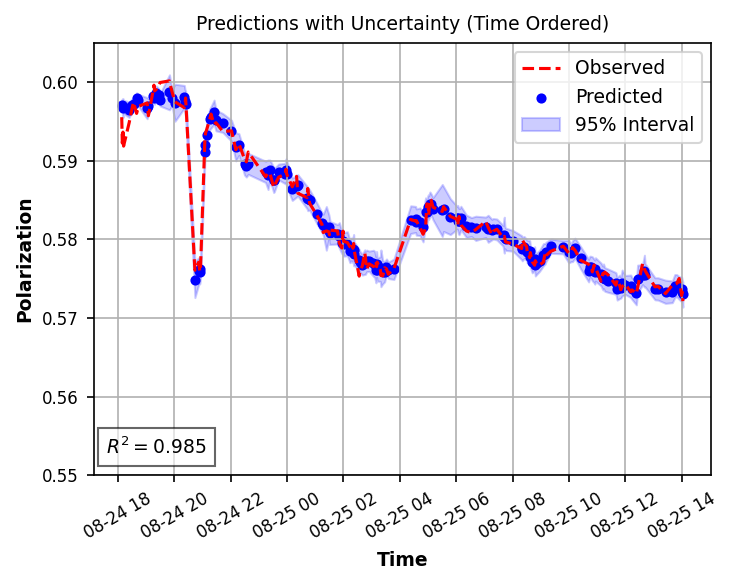

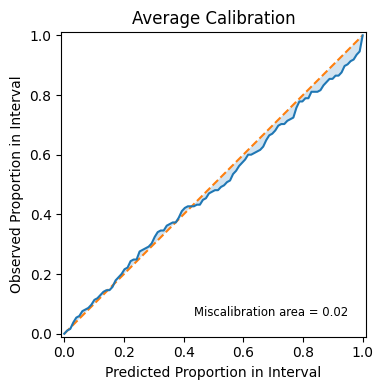

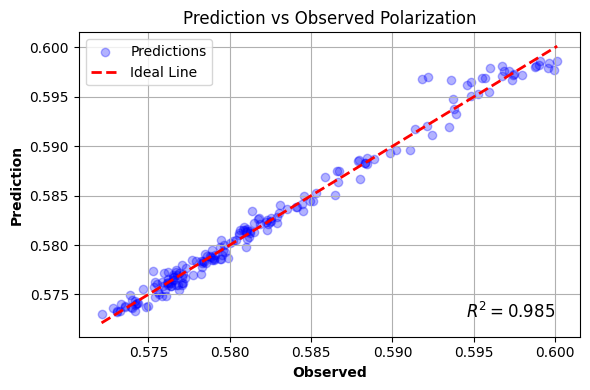

In [7]:
# ==========================
# Gaussian Process (GP) Model – TensorFlow Implementation
# ==========================

import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import uncertainty_toolbox as uct


# ----------------------------
# GP Model Class
# ----------------------------
class GPModelTF:
    def __init__(self, kernel="laplace", lengthscale=1.0, coefficient=1.0, noise=1e-2):
        self.kernel = kernel
        self.lengthscale = lengthscale
        self.coefficient = coefficient
        self.noise = noise
        self.scaler_X = None
        self.scaler_y = None
        self.X_train_norm = None
        self.y_train_norm = None

    def _covariance(self, x1, x2, noise=None):
        """Compute covariance matrix based on the selected kernel."""
        x1 = tf.convert_to_tensor(x1, dtype=tf.float64)
        x2 = tf.convert_to_tensor(x2, dtype=tf.float64)
        diff = tf.expand_dims(x1, 1) - tf.expand_dims(x2, 0)  # [n1, n2, d]

        if self.kernel == "eq":
            l2 = tf.reduce_sum((diff / self.lengthscale) ** 2, axis=2)
            cov = self.coefficient**2 * tf.exp(-0.5 * l2)
        elif self.kernel == "laplace":
            l1 = tf.reduce_sum(tf.abs(diff / self.lengthscale), axis=2)
            cov = self.coefficient**2 * tf.exp(-0.5 * l1)
        elif self.kernel == "cauchy":
            l2 = tf.reduce_sum((diff / self.lengthscale) ** 2, axis=2)
            cov = self.coefficient**2 / (1.0 + l2)
        else:
            raise ValueError("Unknown kernel type")

        if noise is not None:
            cov += noise**2 * tf.eye(tf.shape(cov)[0], dtype=tf.float64)
        return cov

    def fit(self, X_train, y_train):
        """Normalize and store training data."""
        self.scaler_X = StandardScaler()
        self.X_train_norm = self.scaler_X.fit_transform(X_train)

        self.scaler_y = StandardScaler()
        self.y_train_norm = self.scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    def predict(self, X_new):
        """Predict mean and standard deviation for new samples."""
        X_new_norm = self.scaler_X.transform(X_new)

        Kdd = self._covariance(self.X_train_norm, self.X_train_norm, noise=self.noise)
        Kpd = self._covariance(X_new_norm, self.X_train_norm)
        Kpp = self._covariance(X_new_norm, X_new_norm)

        alpha = tf.linalg.solve(Kdd, tf.expand_dims(self.y_train_norm, axis=1))
        mean_norm = tf.matmul(Kpd, alpha)[:, 0]
        cov = Kpp - tf.matmul(Kpd, tf.linalg.solve(Kdd, tf.transpose(Kpd)))
        var_norm = tf.linalg.diag_part(cov)

        mean_orig = self.scaler_y.inverse_transform(mean_norm.numpy().reshape(-1, 1)).flatten()
        std_orig = (var_norm.numpy() ** 0.5) * self.scaler_y.scale_
        return mean_orig, std_orig


# ----------------------------
# Main 
# ----------------------------
if __name__ == "__main__":
    # Load and filter data
    data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
    filtered_data = data[data['SampleID'] == '(P07)']

    # Convert time columns to datetime
    for col in ['start_time', 'end_time']:
        if col in filtered_data.columns:
            filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')

    # Select relevant features
    features = ['scaler_calc1', 'uwave_freq', 'TGT:PT12:Target_Dose']
    target = 'polarization'
    X = filtered_data[features].values
    y = filtered_data[target].values

    # Train-test split (80/20) with reproducibility
    tf.random.set_seed(42)
    indices = tf.range(X.shape[0])
    shuffled = tf.random.shuffle(indices, seed=42)
    split = int(0.8 * X.shape[0])
    train_idx, test_idx = shuffled[:split], shuffled[split:]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

   
    gp_model = GPModelTF(kernel="laplace", lengthscale=1143.51, coefficient=28.13, noise=0.1138) # Hyperparameter values Laplace (L-BFGS-B )
    # gp_model = GPModelTF(kernel="eq", lengthscale=0.64793044, coefficient=1.12894957, noise=0.17412835) # Hyperparameter values RBF (L-BFGS-B )
    # gp_model = GPModelTF(kernel="cauchy", lengthscale=0.35859889, coefficient=0.7329095, noise=0.14447289) # Hyperparameter values Cauchy (L-BFGS-B )

    gp_model.fit(X_train, y_train)

    # Predictions
    mean_pred, std_pred = gp_model.predict(X_test)
    filtered_test = filtered_data.iloc[test_idx].copy()
    filtered_test['Polarization_Prediction'] = mean_pred
    filtered_test['Polarization_Prediction_std'] = std_pred

    # Sort by time
    if 'start_time' in filtered_test.columns:
        filtered_test = filtered_test.sort_values('start_time').reset_index(drop=True)

    # R² score
    r2 = r2_score(filtered_test['polarization'], filtered_test['Polarization_Prediction'])
    print(f"R²: {r2:.3f}")

    # ----------------------------
    # Plot 1: Predictions with Uncertainty over Time
    # ----------------------------
    fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
    ax.plot(filtered_test['start_time'], filtered_test['polarization'], 'r--', label='Observed')
    ax.scatter(filtered_test['start_time'], filtered_test['Polarization_Prediction'],
               s=15, color='blue', label='Predicted')
    ax.fill_between(filtered_test['start_time'],
                    filtered_test['Polarization_Prediction'] - 2 * filtered_test['Polarization_Prediction_std'],
                    filtered_test['Polarization_Prediction'] + 2 * filtered_test['Polarization_Prediction_std'],
                    color='blue', alpha=0.2, label='95% Interval')

    ax.set_xlabel("Time", fontsize=9, fontweight='bold')
    ax.set_ylabel("Polarization", fontsize=9, fontweight='bold')
    ax.set_title("Predictions with Uncertainty (Time Ordered)", fontsize=9)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True)
    ax.set_ylim(0.55, 0.605)
    ax.text(0.02, 0.05, f"$R^2 = {r2:.3f}$", transform=ax.transAxes,
            fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 2: Average Calibration Plot
    # ----------------------------
    uct.viz.plot_calibration(
        filtered_test['Polarization_Prediction'].values,
        filtered_test['Polarization_Prediction_std'].values,
        filtered_test['polarization'].values
    )
    plt.gcf().set_size_inches(4, 4)
    plt.title("Average Calibration")
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Plot 3: Prediction vs Observed
    # ----------------------------
    plt.figure(figsize=(6, 4))
    plt.scatter(filtered_test['polarization'], filtered_test['Polarization_Prediction'],
                alpha=0.3, color='blue', label='Predictions')
    plt.plot([filtered_test['polarization'].min(), filtered_test['polarization'].max()],
             [filtered_test['polarization'].min(), filtered_test['polarization'].max()],
             'r--', lw=2, label="Ideal Line")
    plt.text(0.95, 0.05, f"$R^2 = {r2:.3f}$", transform=plt.gca().transAxes,
             fontsize=12, ha='right', va='bottom')
    plt.xlabel("Observed", fontweight='bold')
    plt.ylabel("Prediction", fontweight='bold')
    plt.title("Prediction vs Observed Polarization")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
